In [1]:
import pandas as pd
import numpy as np
import main
import matplotlib.pyplot as plt
import process as pc
import os

plt.style.use("best_style.mplstyle")

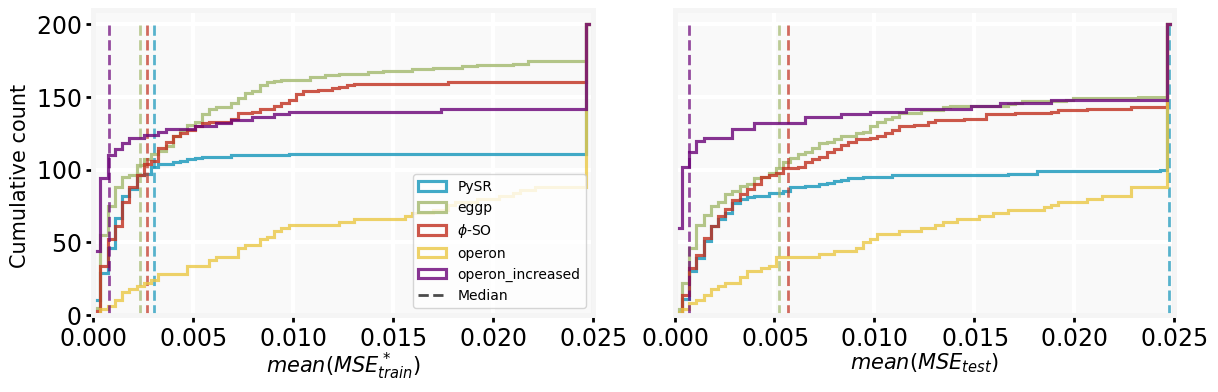

In [2]:
import seaborn as sns


def replace_naninf(array):
    array = np.array(array)
    nans = np.isnan(array)
    if all(~np.isnan(array)):
        return array
    else:
        array[nans] = 999
        return array
    
def smart_nanmean(array):
    if all(np.isnan(array)):
        return np.nan
    else:
        return np.nanmean(array)



colors = [k['color'] for k in list(plt.rcParams['axes.prop_cycle'])]
upper = 0.025
bins = np.linspace(0, upper, 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for bigidx, chi in enumerate(['chi2', 'chi2_test']):

    for idx, method in enumerate(pc.methods):
        distrib = []
        for dataset in pc.datasets:
            for config in pc.configs:
                distrib += list(pd.read_pickle(f"results/{method}/{dataset}_{config}.pkl")[chi].apply(smart_nanmean))
    
        distrib = replace_naninf(distrib)
        median = np.median(distrib)
        distrib[distrib!=distrib] = upper
        distrib[distrib>upper] = upper


        if method == 'PhySO':
            method = '$\\phi$-SO'

        #axes[bigidx].hist(distrib, bins=bins, alpha=.05, histtype='bar', linewidth=2, color=colors[idx], cumulative=1)
        axes[bigidx].hist(distrib, bins=bins, label=method, alpha=.8, histtype='step', linewidth=2.25, color=colors[idx], cumulative=1)
        axes[bigidx].vlines(median, ymin=0, ymax=200, color=colors[idx], linestyles='dashed', linewidth=2, alpha=.7)
        
    axes[bigidx].vlines(-10, ymin=0, ymax=200, color="black", linestyles='dashed', linewidth=2, alpha=.7, label='Median')
    axes[bigidx].set_xlabel([f"$mean(MSE^*_{{train}})$", f"$mean(MSE_{{test}})$"][bigidx], labelpad=0, fontsize=15)
    axes[bigidx].set_xlim(0, upper)
fig.text(-0.01, 0.55, 'Cumulative count', va='center', rotation='vertical', fontsize=15)
axes[0].legend(fontsize=10, loc="lower right")
axes[1].tick_params(axis='y',which='both', left=False,labelleft=False)

fig.tight_layout(pad=1)



plt.savefig(f"analysis/plots/mean_statistics.png", bbox_inches='tight')
plt.savefig(f"analysis/plots/mean_statistics.pdf", bbox_inches='tight')


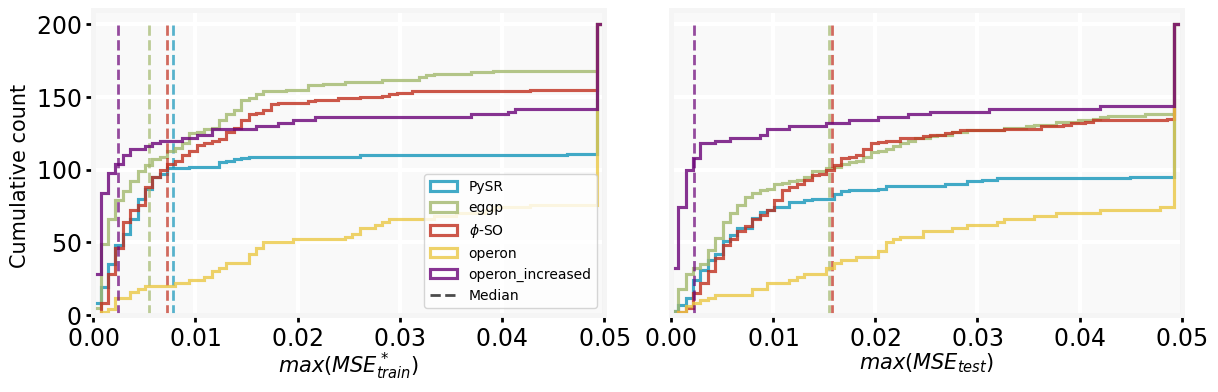

In [3]:
import seaborn as sns

colors = [k['color'] for k in list(plt.rcParams['axes.prop_cycle'])]
upper = 0.05
bins = np.linspace(0, upper, 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for bigidx, chi in enumerate(['chi2', 'chi2_test']):

    for idx, method in enumerate(pc.methods):
        distrib = []
        for dataset in pc.datasets:
            for config in pc.configs:
                distrib += list(pd.read_pickle(f"results/{method}/{dataset}_{config}.pkl")[chi].apply(max))
    
        distrib = replace_naninf(distrib)
        median = np.median(distrib)
        distrib[distrib!=distrib] = upper
        distrib[distrib>upper] = upper

        if method == 'PhySO':
            method = '$\\phi$-SO'

        axes[bigidx].hist(distrib, bins=bins, label=method, alpha=.8, histtype='step', linewidth=2.25, color=colors[idx], cumulative=1)


        axes[bigidx].vlines(median, ymin=0, ymax=200, linestyles='dashed', color=colors[idx], linewidth=2, alpha=.7)

    axes[bigidx].vlines(-10, ymin=0, ymax=200, color="black", linestyles='dashed', linewidth=2, alpha=.7, label='Median')
    axes[bigidx].set_xlabel([f"$max(MSE^*_{{train}})$", f"$max(MSE_{{test}})$"][bigidx], labelpad=0, fontsize=15)
    axes[bigidx].set_xlim(0, upper)
fig.text(-0.01, 0.55, 'Cumulative count', va='center', rotation='vertical', fontsize=15)
axes[0].legend(fontsize=10, loc="lower right")
axes[1].tick_params(axis='y',which='both', left=False,labelleft=False)

fig.tight_layout(pad=1)


plt.savefig(f"analysis/plots/max_statistics.png", bbox_inches='tight')
plt.savefig(f"analysis/plots/max_statistics.pdf", bbox_inches='tight')


np.square(0.1656917 + (t[0] + ((1.0499666 / (x[:, 0] + np.exp(((np.exp(t[1]) ** -0.47677577) / 0.32858637) + ((x[:, 0] - np.exp(np.exp(t[1]))) ** t[0])))) * x[:, 0])))
PySR : big_simple
(t[0] * (x[:, 0] / ((x[:, 0] * (x[:, 0] / (t[1] + np.abs(x[:, 0])))) + (t[1] + (t[1] / np.log((x[:, 0] + np.log(np.abs((x[:, 0] + ((t[1] / x[:, 0]) + t[1])))))))))))
eggp : big_simple
(0.22558648434077785**((t[1]**(((((t[1]*(0.9999898297486759+x[:, 0]))+0.22558648434077785))**(0.5))/t[0]))/0.22558648434077785))
PhySO : big_simple
t[0]*np.abs(x[:, 0])**t[1]
operon : small_simple


<string>:1: RuntimeWarning: invalid value encountered in power


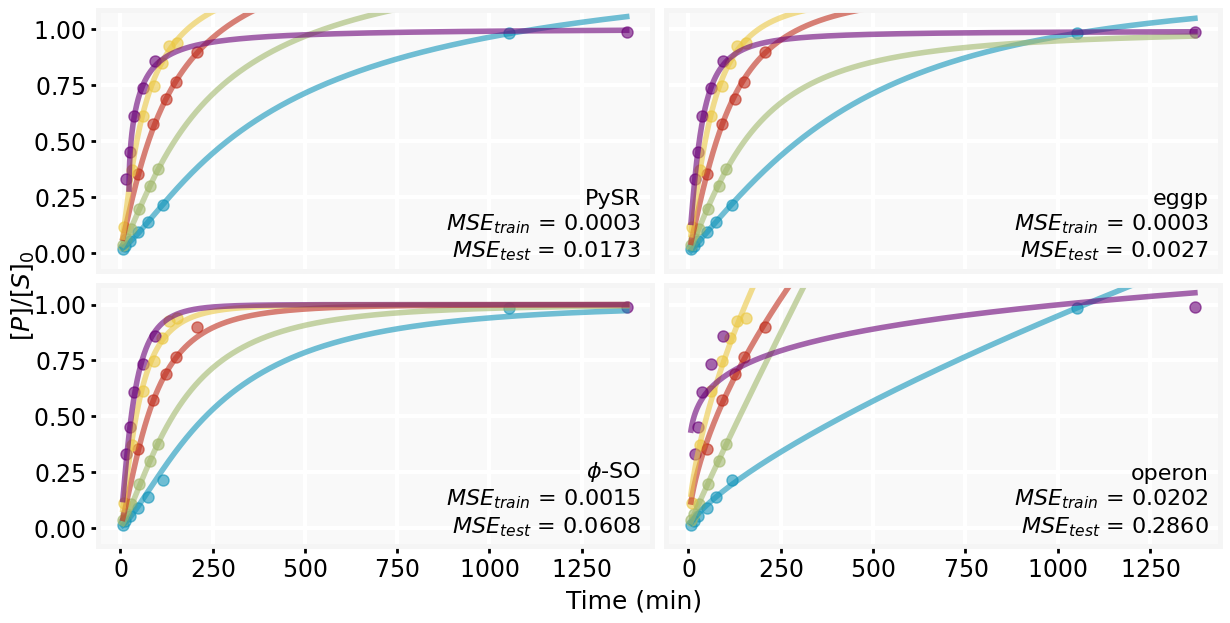

In [4]:
fig, axes = pc.plot_all_bests('biology', xlabel='Time (min)', ylabel='$[P]/[S]_0$', show_n=7)
plt.savefig("analysis/plots/biology_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/biology_results.pdf", bbox_inches='tight')

t[0] + np.sqrt(x[:, 0] ** ((0.16240911 ** x[:, 0]) + t[1]))
PySR : small_simple
(t[0] + (((x[:, 0] * t[1]) + (((t[2] + ((np.log(x[:, 0]) * x[:, 0]) + np.sqrt(x[:, 0]))) / np.sqrt(x[:, 0])) + t[3])) * np.log(x[:, 0])))
eggp : big_complex
np.abs(((t[0]/((((x[:, 0]**1.4082003681105686)/t[1])+t[1])/x[:, 0]))**t[2]))
PhySO : small_complex
t[0]*((-t[1] + t[2]*np.exp(-t[3]*x[:, 0]))**4)**t[4]
operon : big_simple


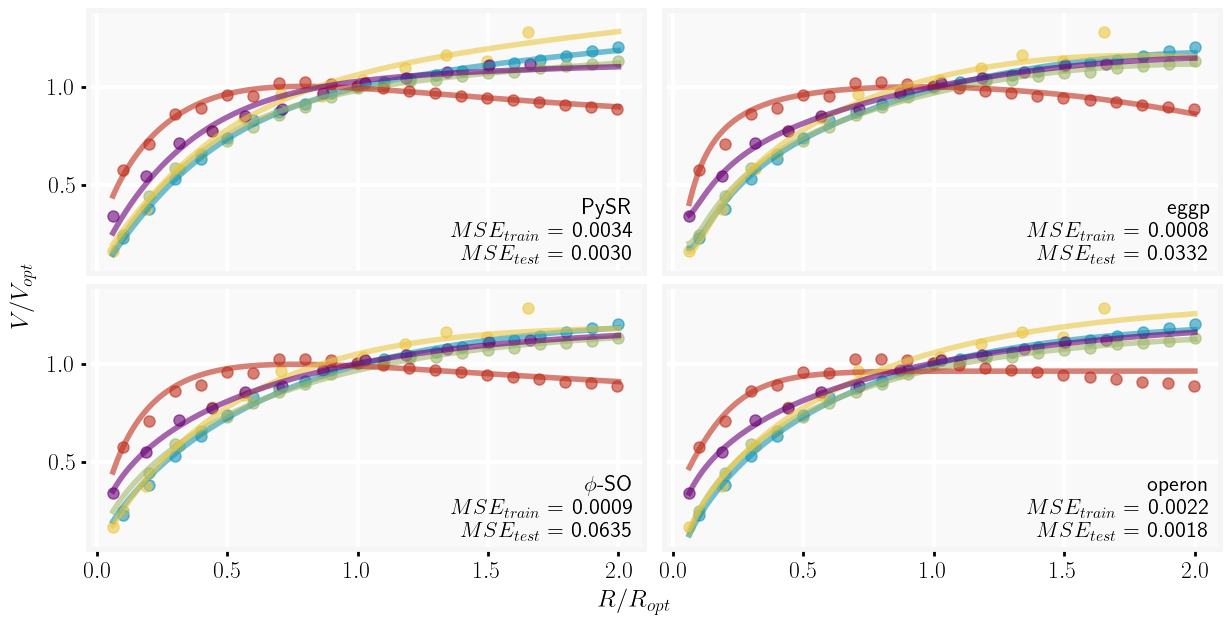

In [13]:
fig, axes = pc.plot_all_bests('galaxies', xlabel='$R/R_{opt}$', ylabel='$V/V_{opt}$',show_n=5)
plt.savefig("analysis/plots/galaxy_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/galaxy_results.pdf", bbox_inches='tight')

np.sqrt(-0.226887 + (np.exp(np.abs(((3.3238091 / np.exp(x[:, 0])) / t[0]) + 0.212852)) * np.sqrt(np.abs(t[0]))))
PySR : big_simple
(((t[0] / ((((x[:, 0] * x[:, 0]) + t[0]) * ((np.sqrt(x[:, 0]) / x[:, 0]) - x[:, 0])) - np.exp(x[:, 0]))) * x[:, 0]) + np.exp((t[1] / (x[:, 0] + t[1]))))
eggp : big_simple
(np.exp(((np.abs(((((np.log(x[:, 0])+t[0])+-1.9400568023507851))**(0.5)))*x[:, 0])-x[:, 0]))+t[0])
PhySO : small_simple
t[0]/x[:, 0]**t[1] + t[2]*x[:, 0]**2 - t[3]*x[:, 0]
operon : small_simple


<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: invalid value encountered in sqrt
<string>:1: RuntimeWarning: invalid value encountered in sqrt
<string>:1: RuntimeWarning: invalid value encountered in sqrt
<string>:1: RuntimeWarning: invalid value encountered in sqrt
<string>:1: RuntimeWarning: invalid value encountered in sqrt


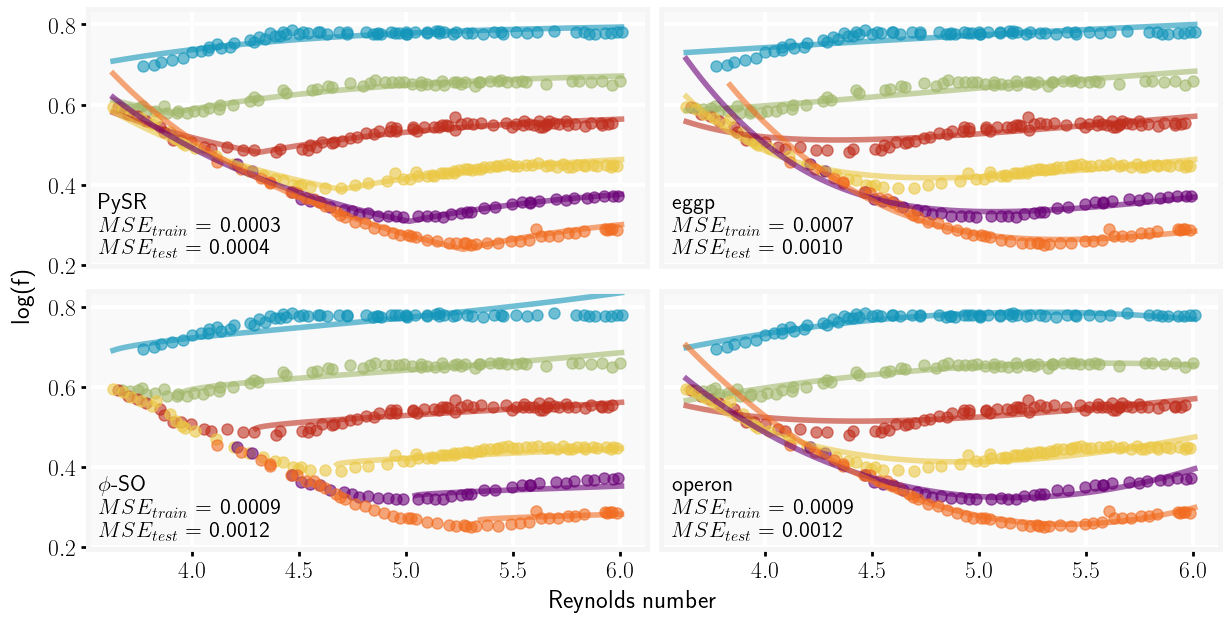

In [14]:
fig, axes = pc.plot_all_bests('fluid', xlabel='Reynolds number', ylabel='log(f)', show_n=6, horizontalalignment='left', method_pos=(0.02, 0.03))

plt.savefig("analysis/plots/fluid_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/fluid_results.pdf", bbox_inches='tight')

(11.222773 + t[0]) * (0.58161664 ** np.exp((t[2] + x[:, 0]) * t[1]))
PySR : small_complex
((t[0] + (x[:, 0] * t[1])) / (t[2] - np.exp(np.sqrt(np.exp((x[:, 0] + t[2]))))))
eggp : big_complex
((t[1]+6.5724305797790885)/(np.exp((x[:, 0]-(t[0]*t[0])))+t[1]))
PhySO : small_complex
-t[0]*x[:, 0] - np.exp(-t[1]*(x[:, 0])**2 + t[2]*(x[:, 0]) + t[3]*(x[:, 0])**2) + t[4]
operon : big_simple


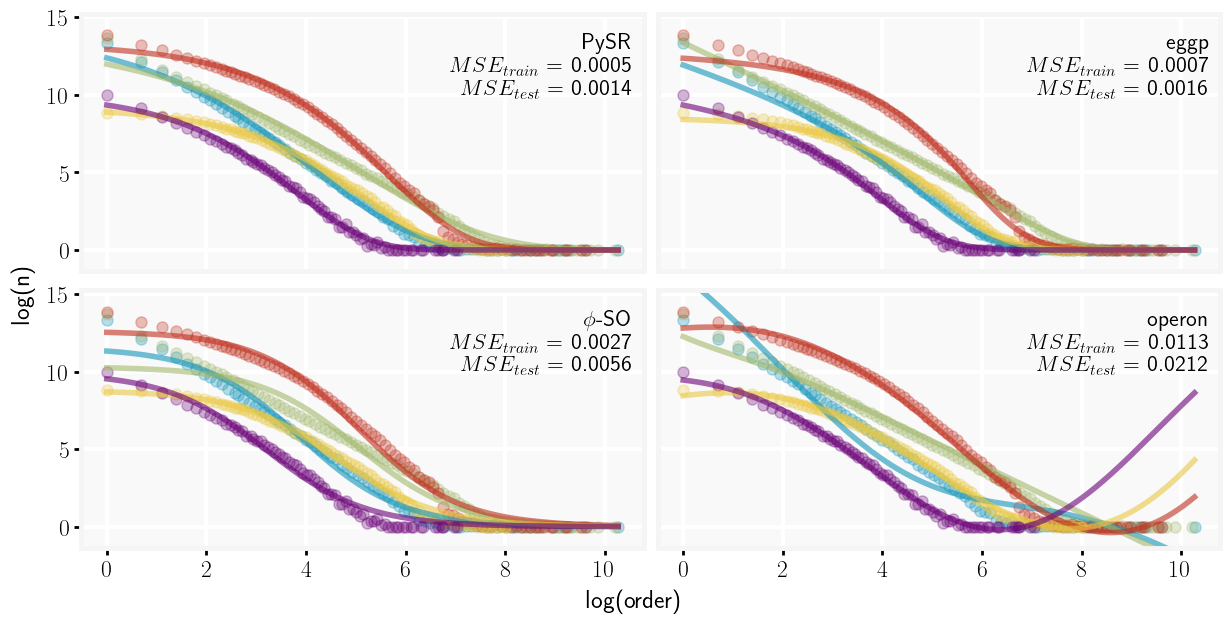

In [15]:
fig, axes = pc.plot_all_bests('graphs', xlabel='log(order)', ylabel='log(n)', show_n=5,
                           method_pos=(0.98, 0.67), scatter_alpha=0.3)
plt.savefig("analysis/plots/graph_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/graph_results.pdf", bbox_inches='tight')

(0.96327823 ** (np.square((0.89328545 + (t[1] * x[:, 0])) + (0.32820454 / t[0])) + np.sqrt(np.square(x[:, 0] + 1.7782171) + (0.5889515 ** x[:, 0])))) / 0.89241004
PySR : big_simple
(t[0] * np.sqrt(np.abs((t[1] / (np.abs((t[2] + (t[3] / np.abs(np.abs(np.exp((t[1] * x[:, 0]))))))) + np.exp((t[1] * (t[1] * x[:, 0]))))))))
eggp : big_complex
np.abs((((((((np.abs(np.abs(((0.7906930222298797**x[:, 0])+t[1]))))**(0.5))**x[:, 0])**t[0]))**(0.5))**0.12133517123358101))
PhySO : big_complex
(np.exp(-t[0]*x[:, 0])**(t[1]*x[:, 0]))**0.5
operon : small_simple


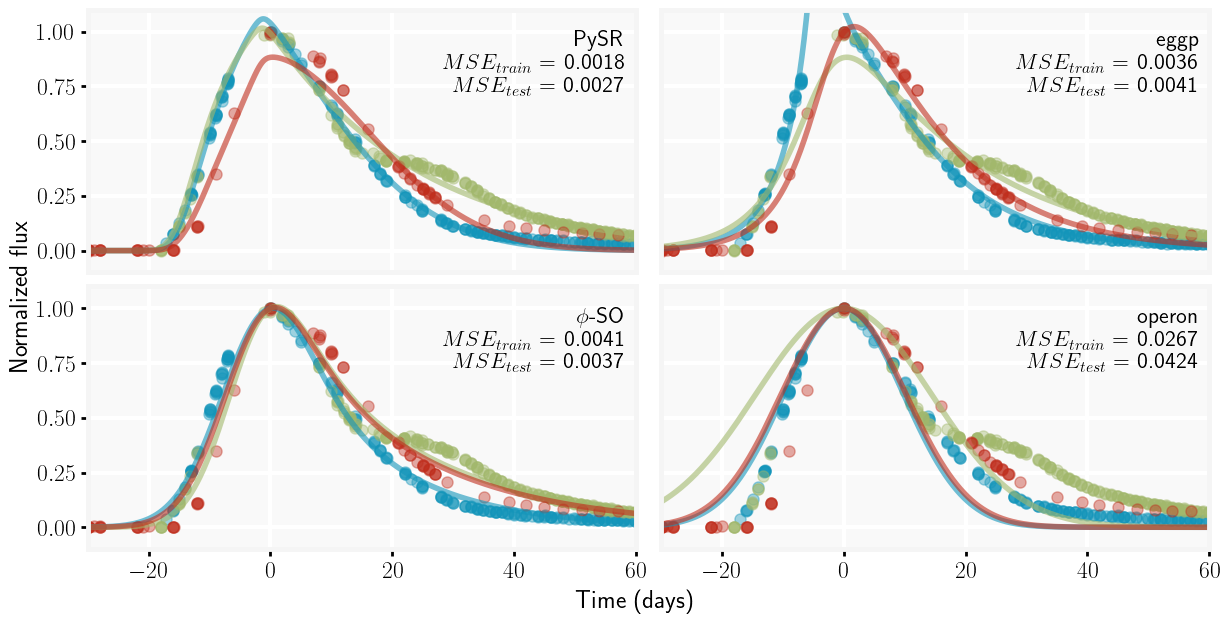

In [16]:
fig, axes = pc.plot_all_bests('supernovae', xlabel='Time (days)', ylabel='Normalized flux', show_n=3,
                           method_pos=(0.98, 0.67), scatter_alpha=0.4, xlim=(-30, 60))
plt.savefig("analysis/plots/supernovae_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/supernovae_results.pdf", bbox_inches='tight')

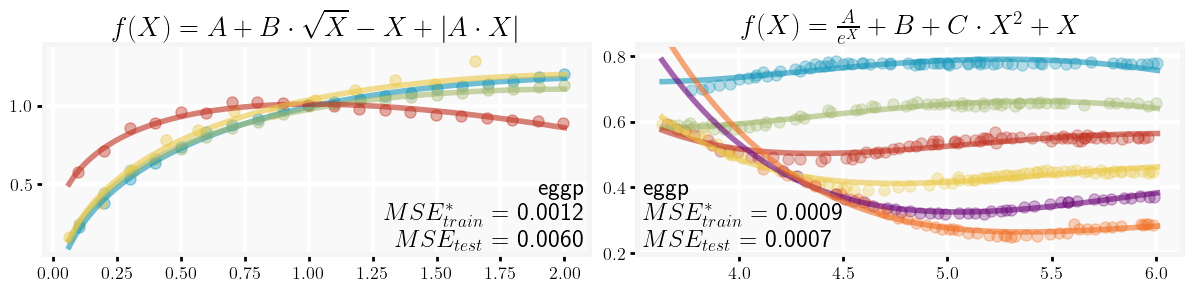

In [17]:
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True

datasets = ['galaxies', 'fluid', 'graphs']
methods = ['eggp', 'eggp', 'eggp']
hypers = ['small_simple', 'small_complex', 'big_complex']
expressions = [pc.summary_tables('expression')[datasets[i]].loc[hypers[i], methods[i]] for i in range(3)]
best_params = [pc.summary_tables('parameters')[datasets[i]].loc[hypers[i], methods[i]]for i in range(3)]
latexes = [pc.generate_latex(expressions[i]) for i in range(3)]
latexes[1] = latexes[1].replace('X \\cdot X', 'X^2')
chi2s = [pc.summary_tables('chi2')[datasets[i]].loc[hypers[i], methods[i]] for i in range(3)]
chi2s_test = [pc.summary_tables('chi2_test')[datasets[i]].loc[hypers[i], methods[i]] for i in range(3)]

fig, axes = plt.subplots(1,2,figsize=(12, 3),)

i=0

pc.plot_solution(axes.flatten()[i], datasets[i], main.make_function(expressions[i]),
                 best_params[i], show_n=4, title=latexes[i], scatter_alpha=0.4, xlim=None)
title1 = f"$f(X)={latexes[i]}$"
axes.flatten()[i].set_title(title1, fontsize=20)
axes.flatten()[i].text(.99, .01, f"{methods[i]}\n$MSE^*_{{train}}$ = {chi2s[i]:.4f}\n$MSE_{{test}}$ = {chi2s_test[i]:.4f}",
        transform=axes.flatten()[i].transAxes, horizontalalignment='right', verticalalignment='bottom', fontsize=18)

i=1
pc.plot_solution(axes.flatten()[i], datasets[i], main.make_function(expressions[i]),
                 best_params[i], show_n=6, title=None, scatter_alpha=0.3, xlim=None)
title2 = f"$f(X)={latexes[i]}$"
axes.flatten()[i].set_title(title2, fontsize=20)
axes.flatten()[i].text(.01, .01, f"{methods[i]}\n$MSE^*_{{train}}$ = {chi2s[i]:.4f}\n$MSE_{{test}}$ = {chi2s_test[i]:.4f}",
        transform=axes.flatten()[i].transAxes, horizontalalignment='left', verticalalignment='bottom', fontsize=18)


for i in range(2):
    axes.flatten()[i].xaxis.set_tick_params(labelsize=13)
    axes.flatten()[i].yaxis.set_tick_params(labelsize=13)

fig.tight_layout(pad=1)



plt.savefig("analysis/plots/halloffame.pdf", bbox_inches='tight')
plt.savefig("analysis/plots/halloffame.png", bbox_inches='tight')

biology PySR 0.017328239972087885
                     PySR      eggp     PhySO    operon operon_increased
small_simple          NaN  2.296147  1.315305   0.28602         0.002886
small_complex    1.038863  0.479611  0.088424   0.28602         0.002886
big_simple       0.017328  0.002688  0.060827  0.063641         1.180237
big_complex    679.293408  0.007467  0.036833  0.063641         1.180237


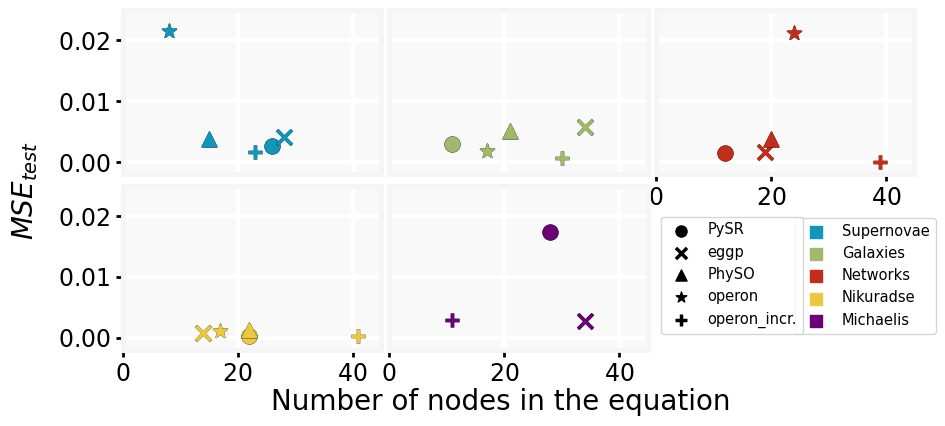

In [17]:
colors = [k['color'] for k in list(plt.rcParams['axes.prop_cycle'])]
markers = ["o", "x", "^", "*", "+"]

for what in ['chi2_test']:

    fig, axes = plt.subplots(2, 3, figsize=(9, 4))
    fig.delaxes(axes.flat[5])

    for idx2, dataset in enumerate(pc.datasets):
    
        pareto_chi, pareto_complex = [], []
        
        chi2s = pc.summary_tables(what)[dataset]
        expressions = pc.summary_tables('expression')[dataset]
        parameters = pc.summary_tables('parameters')[dataset]
        bests = np.nanargmin(chi2s, axis=0)
        for idx, method in enumerate(pc.methods):
            
            best_idx = int(bests[idx])
            expression = expressions[method].iloc[best_idx]
            chi2 = chi2s[method].iloc[best_idx]
            complexity = pc.sizeOf(expression)
    
            pareto_chi.append(chi2)
            pareto_complex.append(complexity)
            if (method == "PySR") and (dataset=='biology'):
                print(dataset, method, chi2)
                print(chi2s)
            axes.flat[idx2].scatter(complexity, chi2, color='black', marker=markers[idx], s=115)
            axes.flat[idx2].scatter(complexity, chi2, color=colors[idx2], marker=markers[idx], s=110)


            if what == 'chi2':
                axes.flat[idx2].set_ylim(0, 0.005)
                axes.flat[idx2].set_xlim(0, 45)

            else:
                axes.flat[idx2].set_ylim(-0.002, 0.025)
                axes.flat[idx2].set_xlim(0, 45)
                
    
    
    
    for k in [0, 1]:
        axes.flat[k].set_xticklabels([])  # Remove x-axis ticks
        axes.flat[k].tick_params(axis='x', length=0) # Remove tick marks
    
    for k in [1, 2, 4]:
        axes.flat[k].set_yticklabels([])  # Remove x-axis ticks
        axes.flat[k].tick_params(axis='y', length=0) # Remove tick marks
    
    
    
    for k in range(len(markers)):
        axes.flat[4].scatter(1, 1, marker=markers[k],
                             label=['PySR', 'eggp', 'PhySO', 'operon', 'operon_incr.'][k],
                             color='black')
    
    for k in range(5):
        axes.flat[3].scatter(1, 1, marker='s',
                             label=['Supernovae', 'Galaxies', 'Networks', 'Nikuradse', 'Michaelis'][k],
                             color=colors[k])
        
    fig.text(0.5, -0.05, 'Number of nodes in the equation', ha='center', fontsize=20)

    if what == 'chi2':
        fig.text(-0.05, 0.5, f"$MSE^*_{{train}}$", va='center', rotation='vertical', fontsize=20)

    else:
        fig.text(-0.045, 0.5, f"$MSE_{{test}}$", va='center', rotation='vertical', fontsize=20)

    plt.subplots_adjust(wspace=0.03, hspace=0.07)
    
    axes.flat[4].legend(fontsize=10.5, loc=[1.05, 0.1])
    axes.flat[3].legend(fontsize=10.5, loc=[2.6, 0.1])
    
    plt.savefig(f"analysis/plots/pareto_front_{what}.pdf", bbox_inches='tight')
    plt.savefig(f"analysis/plots/pareto_front_{what}.png", bbox_inches='tight')


In [11]:
computation_time = pd.DataFrame(columns=['PySR', 'eggp', 'PhySO', 'operon', 'operon_increased'], index=pc.datasets)

for idx2, dataset in enumerate(pc.datasets):
    times = np.mean(pc.summary_tables('time')[dataset], axis=0)
    times = np.array(list(times)).round(1)
    computation_time.loc[dataset] = times

computation_time

,PySR,eggp,PhySO,operon,operon_increased
supernovae,892.9,43.3,1042.6,0.1,2.2
galaxies,1785.6,83.0,801.9,0.3,7.9
graphs,574.8,45.2,601.0,0.1,2.6
fluid,505.2,30.7,673.0,0.1,2.2
biology,90.1,19.4,790.8,0.1,1.3
